# TP — Gymnasium avec Taxi-v3 et MiniGrid-Empty-16x16-v0

Complétez les cellules demandées. Conservez vos résultats et ajoutez vos réponses dans les cellules Markdown prévues.

## 0. Installation
Décommentez les lignes si nécessaire.

In [1]:
%pip install gymnasium
%pip install "gymnasium[toy-text]"
%pip install minigrid

print("Décommentez les installations si nécessaire.")

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.
Décommentez les installations si nécessaire.



[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt

print(gym.__version__)

1.2.3


## 1. Découverte de Taxi-v3

In [3]:
# TODO
# Créer l'environnement Taxi-v3
env = gym.make("Taxi-v3")
# Afficher action_space, observation_space, spec et unwrapped
print("Action space :", env.action_space)
print("Observation space :", env.observation_space)
print("Metadata :", env.spec)
print("Spec :", env.unwrapped)
# Quelques actions aléatoires pour observer les retours de step()
obs, info = env.reset(seed=42)
print("\nObservation initiale :", obs)
print(env.render())

print("\n5 actions aléatoires")
for i in range(5):
    action = env.action_space.sample()
    obs, reward, terminated, truncated, info = env.step(action)
    print(f"  action={action}  obs={obs}  reward={reward}  "
          f"terminated={terminated}  truncated={truncated}  info={info}")

env.close()


Action space : Discrete(6)
Observation space : Discrete(500)
Metadata : EnvSpec(id='Taxi-v3', entry_point='gymnasium.envs.toy_text.taxi:TaxiEnv', reward_threshold=8, nondeterministic=False, max_episode_steps=200, order_enforce=True, disable_env_checker=False, kwargs={}, namespace=None, name='Taxi', version=3, additional_wrappers=(), vector_entry_point=None)
Spec : <TaxiEnv<Taxi-v3>>

Observation initiale : 386
None

5 actions aléatoires
  action=3  obs=366  reward=-1  terminated=False  truncated=False  info={'prob': 1.0, 'action_mask': array([1, 1, 1, 0, 0, 0], dtype=int8)}
  action=1  obs=266  reward=-1  terminated=False  truncated=False  info={'prob': 1.0, 'action_mask': array([1, 1, 1, 1, 0, 0], dtype=int8)}
  action=3  obs=246  reward=-1  terminated=False  truncated=False  info={'prob': 1.0, 'action_mask': array([1, 1, 1, 1, 0, 0], dtype=int8)}
  action=2  obs=266  reward=-1  terminated=False  truncated=False  info={'prob': 1.0, 'action_mask': array([1, 1, 1, 1, 0, 0], dtype=int8)}

C:\Users\lenovo\AppData\Roaming\Python\Python313\site-packages\gymnasium\envs\toy_text\taxi.py:443: UserWarning: WARN: You are calling render method without specifying any render mode. You can specify the render_mode at initialization, e.g. gym.make("Taxi-v3", render_mode="rgb_array")
  gym.logger.warn(


**Réponse attendue :** décrivez brièvement ce que représente Taxi-v3 et pourquoi cet environnement est utile pour commencer.

Taxi-v3 est un environnement de grille 5×5 dans lequel un taxi doit aller chercher un passager à l'un des 4 emplacements fixes (R, G, Y, B), l'embarquer (action *pickup*), puis le déposer à la destination (action *dropoff*).

## 2. Premier épisode avec actions aléatoires

In [4]:
# TODO
# Exécuter un épisode aléatoire complet
# Afficher le nombre d'étapes, la récompense cumulée et la cause d'arrêt
env = gym.make("Taxi-v3")
obs, info = env.reset(seed=42)

total_reward = 0
steps = 0
terminated = False
truncated = False

while not (terminated or truncated):
    action = env.action_space.sample()
    obs, reward, terminated, truncated, info = env.step(action)
    total_reward += reward
    steps += 1

cause = "terminated (succès)" if terminated else "truncated (limite atteinte)"
print(f"Nombre d'étapes   : {steps}")
print(f"Récompense totale : {total_reward}")
print(f"Cause d'arrêt     : {cause}")

env.close()

Nombre d'étapes   : 200
Récompense totale : -758
Cause d'arrêt     : truncated (limite atteinte)


**Analyse :** que remarquez-vous sur les performances de cette politique ?

La récompense totale est très négative -731. La politique aléatoire choisit chaque action avec probabilité 1/6 sans tenir compte du contexte : elle effectue fréquemment des pickup et dropoff illégaux (−10 chacun) et erre longtemps dans la grille avant de trouver le passager ou la destination, accumulant les pénalités de −1 par étape.

## 3. Politique aléatoire sur plusieurs épisodes

In [5]:
# TODO
# Écrire une fonction random_taxi_policy(obs, env)
def random_taxi_policy(obs, env):
    return env.action_space.sample()
def run_episodes(policy_fn, env_id="Taxi-v3", n_episodes=20, max_steps=200, seed=0):
    env = gym.make(env_id)
    results = []
    for ep in range(n_episodes):
        obs, info = env.reset(seed=seed + ep)
        total_reward = 0
        steps = 0
        terminated = truncated = False
        while not (terminated or truncated) and steps < max_steps:
            action = policy_fn(obs, env)
            obs, reward, terminated, truncated, info = env.step(action)
            total_reward += reward
            steps += 1
        results.append({
            "episode": ep,
            "total_reward": total_reward,
            "steps": steps,
            "success": terminated and total_reward > 0
        })
    env.close()
    return results
# Lancer au moins 20 épisodes
results_random = run_episodes(random_taxi_policy, n_episodes=20, seed=0)

# Stocker les résultats dans une liste ou un dictionnaire
print(f"{'Ep':>3}  {'Reward':>8}  {'Étapes':>7}  {'Succès':>7}")
print("-" * 35)
for r in results_random:
    print(f"{r['episode']:>3}  {r['total_reward']:>8.1f}  {r['steps']:>7}  {str(r['success']):>7}")

 Ep    Reward   Étapes   Succès
-----------------------------------
  0    -776.0      200    False
  1    -785.0      200    False
  2    -373.0      106    False
  3    -731.0      200    False
  4    -884.0      200    False
  5    -785.0      200    False
  6    -857.0      200    False
  7    -704.0      200    False
  8    -929.0      200    False
  9    -785.0      200    False
 10    -848.0      200    False
 11    -740.0      200    False
 12    -839.0      200    False
 13    -731.0      200    False
 14    -722.0      200    False
 15    -848.0      200    False
 16    -794.0      200    False
 17    -285.0       72    False
 18    -821.0      200    False
 19    -803.0      200    False


In [6]:
# TODO
# Calculer les indicateurs moyens : récompense, longueur, taux de succès
rewards   = [r["total_reward"] for r in results_random]
steps_all = [r["steps"] for r in results_random]
successes = [r["success"] for r in results_random]

print("Politique aléatoire: 20 épisodes")
print(f"  Récompense moyenne : {np.mean(rewards):.2f}  (std={np.std(rewards):.2f})")
print(f"  Étapes moyennes    : {np.mean(steps_all):.1f}")
print(f"  Taux de succès     : {np.mean(successes)*100:.1f} %")

Politique aléatoire: 20 épisodes
  Récompense moyenne : -752.00  (std=152.43)
  Étapes moyennes    : 188.9
  Taux de succès     : 0.0 %


## 4. Politique aléatoire contrainte sur Taxi-v3

Utilisez les informations disponibles dans l’environnement pour éviter autant que possible les actions manifestement invalides.

In [7]:
# TODO
# Implémenter une politique aléatoire contrainte
TAXI_LOCS = [(0, 0), (0, 4), (4, 0), (4, 3)]

def constrained_random_taxi_policy(obs, env):
    row, col, pass_loc, dest_idx = env.unwrapped.decode(int(obs))
    passenger_in_taxi = (pass_loc == 4)

    forbidden = []

    if not passenger_in_taxi:
        # Pickup valide seulement si taxi sur la case du passager
        pr, pc = TAXI_LOCS[pass_loc]
        if not (row == pr and col == pc):
            forbidden.append(4)
        forbidden.append(5)
    else:
        # Dropoff valide seulement sur la destination
        dr, dc = TAXI_LOCS[dest_idx]
        if not (row == dr and col == dc):
            forbidden.append(5)
        forbidden.append(4)

    valid_actions = [a for a in range(env.action_space.n) if a not in forbidden]
    return int(np.random.choice(valid_actions))

In [8]:
# TODO
# Comparer la politique aléatoire simple et la politique contrainte
results_constrained = run_episodes(constrained_random_taxi_policy, n_episodes=20, seed=0)

def summarize(results, label):
    rewards   = [r["total_reward"] for r in results]
    steps_all = [r["steps"] for r in results]
    successes = [r["success"] for r in results]
    print(f"\n{label}")
    print(f"  Récompense moy. : {np.mean(rewards):.2f}  (std={np.std(rewards):.2f})")
    print(f"  Étapes moy.     : {np.mean(steps_all):.1f}")
    print(f"  Taux de succès  : {np.mean(successes)*100:.1f} %")

summarize(results_random,      "Aléatoire (20 épisodes)")
summarize(results_constrained, "Contrainte (20 épisodes)")


Aléatoire (20 épisodes)
  Récompense moy. : -752.00  (std=152.43)
  Étapes moy.     : 188.9
  Taux de succès  : 0.0 %

Contrainte (20 épisodes)
  Récompense moy. : -182.35  (std=43.12)
  Étapes moy.     : 185.5
  Taux de succès  : 0.0 %


**Analyse :** expliquez pourquoi ce filtrage améliore ou non les résultats.

Le filtrage **améliore** les résultats car il supprime les actions qui génèrent une pénalité de −10 (pickup/dropoff illégaux). En éliminant ces choix invalides, la politique évite de dilapider sa récompense sur des fautes. Elle reste cependant limitée : elle choisit encore aléatoirement parmi les déplacements (N/S/E/O) sans chercher à se rapprocher du passager ou de la destination.

## 5. Politique heuristique simple pour Taxi-v3

In [9]:
# TODO
# Décoder l'état de Taxi-v3
# Indice : utilisez env.unwrapped.decode(obs) si nécessaire
env_demo = gym.make("Taxi-v3")
obs, _ = env_demo.reset(seed=0)

row, col, pass_loc, dest_idx = env_demo.unwrapped.decode(int(obs))
locs_names = ["R(0,0)", "G(0,4)", "Y(4,0)", "B(4,3)"]

print(f"Observation brute : {obs}")
print(f"  Taxi position   : ligne={row}, col={col}")
print(f"  Passager        : {locs_names[pass_loc] if pass_loc < 4 else 'dans le taxi'}")
print(f"  Destination     : {locs_names[dest_idx]}")

env_demo.close()

Observation brute : 314
  Taxi position   : ligne=3, col=0
  Passager        : B(4,3)
  Destination     : Y(4,0)


In [10]:
# TODO
# Implémenter heuristic_taxi_policy(obs, env)
SOUTH, NORTH, EAST, WEST, PICKUP, DROPOFF = 0, 1, 2, 3, 4, 5
TAXI_LOCS = [(0, 0), (0, 4), (4, 0), (4, 3)]  # R, G, Y, B

def move_toward(row, col, tr, tc):
    if row < tr:
        return SOUTH
    elif row > tr:
        return NORTH
    elif col < tc:
        return EAST
    else:
        return WEST


def heuristic_taxi_policy(obs, env):
    row, col, pass_loc, dest_idx = env.unwrapped.decode(int(obs))
    passenger_in_taxi = (pass_loc == 4)

    if not passenger_in_taxi:
        # aller chercher le passager
        pr, pc = TAXI_LOCS[pass_loc]
        if row == pr and col == pc:
            return PICKUP           # embarquer
        return move_toward(row, col, pr, pc)
    else:
        # déposer le passager à la destination
        dr, dc = TAXI_LOCS[dest_idx]
        if row == dr and col == dc:
            return DROPOFF          # déposer
        return move_toward(row, col, dr, dc)

In [11]:
# TODO
# Évaluer cette politique sur plusieurs épisodes
results_heuristic = run_episodes(heuristic_taxi_policy, n_episodes=20, seed=0)
summarize(results_heuristic, "Heuristique (20 épisodes)")


Heuristique (20 épisodes)
  Récompense moy. : -147.05  (std=91.72)
  Étapes moy.     : 152.3
  Taux de succès  : 25.0 %


**Analyse :** quels éléments d’observation avez-vous utilisés ? Quels cas particuliers avez-vous dû gérer ?

Éléments utilisés : les 4 composantes décodées → `row`, `col` (position du taxi), `pass_loc` (emplacement du passager ou `4` s'il est embarqué), `dest_idx` (index de la destination).

Cas particuliers gérés :
- Détecter `pass_loc == 4` pour basculer de la phase 1 (aller chercher) à la phase 2 (livrer).
- Ne faire *pickup* que lorsque le taxi est exactement sur la case du passager (sinon pénalité −10).
- Ne faire *dropoff* que lorsque le taxi est exactement sur la destination (sinon pénalité −10).

## 6. Tableau comparatif pour Taxi-v3

In [12]:
# TODO
# Construire un tableau comparant les trois politiques Taxi
def stats_row(results, label):
    rewards   = [r["total_reward"] for r in results]
    steps_all = [r["steps"] for r in results]
    successes = [r["success"] for r in results]
    return {
        "Politique"       : label,
        "Reward moy."     : round(np.mean(rewards), 2),
        "Reward std"      : round(np.std(rewards), 2),
        "Étapes moy."     : round(np.mean(steps_all), 1),
        "Taux succès (%)" : round(np.mean(successes) * 100, 1)
    }

rows = [
    stats_row(results_random,      "Aléatoire"),
    stats_row(results_constrained, "Contrainte"),
    stats_row(results_heuristic,   "Heuristique"),
]

# Affichage du tableau
header = f"{'Politique':<14} {'Reward moy.':>12} {'Reward std':>11} {'Étapes moy.':>12} {'Succès (%)':>11}"
print(header)
print("-" * len(header))
for row in rows:
    print(f"{row['Politique']:<14} {row['Reward moy.']:>12} {row['Reward std']:>11} "
          f"{row['Étapes moy.']:>12} {row['Taux succès (%)']:>11}")

Politique       Reward moy.  Reward std  Étapes moy.  Succès (%)
----------------------------------------------------------------
Aléatoire            -752.0      152.43        188.9         0.0
Contrainte          -182.35       43.12        185.5         0.0
Heuristique         -147.05       91.72        152.3        25.0


## 7. Découverte de MiniGrid-Empty-16x16-v0

In [13]:
# TODO
# Créer l'environnement MiniGrid-Empty-16x16-v0
# Afficher action_space, type d'observation, clés éventuelles, spec

import gymnasium as gym
import minigrid

env_mg = gym.make("MiniGrid-Empty-16x16-v0")

print("MiniGrid-Empty-16x16-v0 ")
print("action_space      :", env_mg.action_space)
print("observation_space :", env_mg.observation_space)
print("spec              :", env_mg.spec)

obs, info = env_mg.reset(seed=0)
print("\nType de l'observation :", type(obs))

if isinstance(obs, dict):
    print("Clés disponibles      :", list(obs.keys()))
    for k, v in obs.items():
        shape = getattr(v, 'shape', None)
        dtype = getattr(v, 'dtype', type(v))
        print(f"  '{k}' : shape={shape}, dtype={dtype}")

env_mg.close()

C:\Users\lenovo\AppData\Roaming\Python\Python313\site-packages\pygame\pkgdata.py:25: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_stream, resource_exists


MiniGrid-Empty-16x16-v0 
action_space      : Discrete(7)
observation_space : Dict('direction': Discrete(4), 'image': Box(0, 255, (7, 7, 3), uint8), 'mission': MissionSpace(<function EmptyEnv._gen_mission at 0x00000266611374C0>, None))
spec              : EnvSpec(id='MiniGrid-Empty-16x16-v0', entry_point='minigrid.envs:EmptyEnv', reward_threshold=None, nondeterministic=False, max_episode_steps=None, order_enforce=True, disable_env_checker=False, kwargs={'size': 16}, namespace=None, name='MiniGrid-Empty-16x16', version=0, additional_wrappers=(), vector_entry_point=None)

Type de l'observation : <class 'dict'>
Clés disponibles      : ['image', 'direction', 'mission']
  'image' : shape=(7, 7, 3), dtype=uint8
  'direction' : shape=None, dtype=<class 'int'>
  'mission' : shape=None, dtype=<class 'str'>


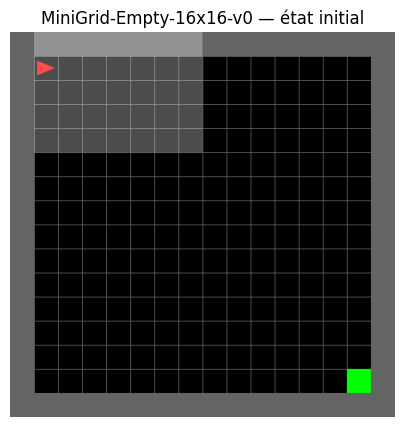

Taille de la frame : (512, 512, 3)


In [14]:
# TODO
# Créer une version avec render_mode="rgb_array"
# Afficher une frame avec matplotlib
env_mg_rgb = gym.make("MiniGrid-Empty-16x16-v0", render_mode="rgb_array")
obs, info = env_mg_rgb.reset(seed=0)
frame = env_mg_rgb.render()

plt.figure(figsize=(5, 5))
plt.imshow(frame)
plt.axis("off")
plt.title("MiniGrid-Empty-16x16-v0 — état initial")
plt.show()
print("Taille de la frame :", frame.shape)

env_mg_rgb.close()


**Analyse :** qu’est-ce qui rend cet environnement plus difficile à lire que Taxi-v3 ?
Dans Taxi-v3, tout est facile à lire car l’état est un nombre clair qui donne directement toutes les information (position, passager, destination).
Dans MiniGrid, c’est plus difficile car :
on voit une image/grille au lieu d’un simple nombre l’agent (triangle rouge) ne voit qu’une petite zone autour de lui (zone grise) une grande partie de la grille est cachée (noir)
il faut interpréter visuellement ce qu’on voit
Donc c’est plus compliqué parce que l’information est partielle elle est visuelle et codée, pas directe et l’agent ne connaît pas toute la carte

## 8. Politique aléatoire sur MiniGrid

In [15]:
# TODO
# Implémenter une politique aléatoire et l'évaluer sur plusieurs épisodes
def random_minigrid_policy(obs, env):
    """Politique entièrement aléatoire pour MiniGrid."""
    return env.action_space.sample()


def run_episodes_mg(policy_fn, env_id="MiniGrid-Empty-16x16-v0",
                    n_episodes=20, max_steps=500, seed=0):
    """Lance n_episodes sur un environnement MiniGrid et retourne les résultats."""
    env = gym.make(env_id)
    results = []
    for ep in range(n_episodes):
        obs, info = env.reset(seed=seed + ep)
        total_reward = 0.0
        steps = 0
        terminated = truncated = False
        while not (terminated or truncated) and steps < max_steps:
            action = policy_fn(obs, env)
            obs, reward, terminated, truncated, info = env.step(action)
            total_reward += reward
            steps += 1
        results.append({
            "episode": ep,
            "total_reward": total_reward,
            "steps": steps,
            "success": terminated
        })
    env.close()
    return results


results_mg_random = run_episodes_mg(random_minigrid_policy, n_episodes=20, seed=0)
summarize(results_mg_random, "MiniGrid — Aléatoire (20 épisodes)")

print("\nDétail par épisode :")
print(f"{'Ep':>3}  {'Reward':>8}  {'Étapes':>7}  {'Succès':>7}")
print("-" * 35)
for r in results_mg_random:
    print(f"{r['episode']:>3}  {r['total_reward']:>8.4f}  {r['steps']:>7}  {str(r['success']):>7}")


MiniGrid — Aléatoire (20 épisodes)
  Récompense moy. : 0.03  (std=0.14)
  Étapes moy.     : 494.1
  Taux de succès  : 5.0 %

Détail par épisode :
 Ep    Reward   Étapes   Succès
-----------------------------------
  0    0.0000      500    False
  1    0.0000      500    False
  2    0.0000      500    False
  3    0.0000      500    False
  4    0.0000      500    False
  5    0.6634      383     True
  6    0.0000      500    False
  7    0.0000      500    False
  8    0.0000      500    False
  9    0.0000      500    False
 10    0.0000      500    False
 11    0.0000      500    False
 12    0.0000      500    False
 13    0.0000      500    False
 14    0.0000      500    False
 15    0.0000      500    False
 16    0.0000      500    False
 17    0.0000      500    False
 18    0.0000      500    False
 19    0.0000      500    False


## 9. Politique réflexe minimale sur MiniGrid

In [16]:
# TODO
# Implémenter une politique à règles locales simples
MG_LEFT, MG_RIGHT, MG_FORWARD = 0, 1, 2

def reflex_minigrid_policy(obs, env):
    """
    Politique réflexe minimale :
    - Lit la case directement devant l'agent dans la vue locale.
      Dans obs['image'] de shape (7,7,3), la case devant est à l'indice [6, 3].
      Le canal 0 encode le type : 2=mur, 1=vide, 8=objectif, etc.
    - Si libre → avancer.
    - Si mur devant → tourner à droite (convention fixe).
    """
    image = obs["image"]          # shape (7, 7, 3)
    cell_ahead_type = image[6, 3, 0]   # case directement devant l'agent

    if cell_ahead_type == 2:      # mur
        return MG_RIGHT
    else:
        return MG_FORWARD


In [17]:
# TODO
# Évaluer cette politique et comparer à l'aléatoire
results_mg_reflex = run_episodes_mg(reflex_minigrid_policy, n_episodes=20, seed=0)
summarize(results_mg_reflex, "MiniGrid — Réflexe (20 épisodes)")

print()
summarize(results_mg_random, "MiniGrid — Aléatoire (20 épisodes) [rappel]")



MiniGrid — Réflexe (20 épisodes)
  Récompense moy. : 0.00  (std=0.00)
  Étapes moy.     : 500.0
  Taux de succès  : 0.0 %


MiniGrid — Aléatoire (20 épisodes) [rappel]
  Récompense moy. : 0.03  (std=0.14)
  Étapes moy.     : 494.1
  Taux de succès  : 5.0 %


**Analyse :** pourquoi cette politique peut-elle tourner en rond ?
Cette politique peut tourner en rond car elle est purement réflexe et ne dispose d’aucune mémoire de l’environnement. L’agent ne peut pas détecter qu’il revisite les mêmes états, ce qui entraîne des cycles de mouvements (par exemple : avancer → mur → tourner → revenir au même endroit). De plus, la stratégie ne permet pas d’exploration dirigée vers l’objectif, ce qui limite fortement les chances d’atteindre le but dans un environnement complexe.


## 10. Politique d’exploration avec mémoire minimale

In [18]:
# TODO
# Implémenter une classe ou une fonction de politique avec mémoire légère
class MemoryPolicy:
    """
    Politique avec mémoire minimale pour MiniGrid.
    Stratégie : longer le mur droit (wall-following) avec détection de boucle.

    Logique :
      1. Si la case à droite est libre → tourner à droite puis avancer (longer le mur).
      2. Sinon si la case devant est libre → avancer.
      3. Sinon → tourner à gauche (dégager un mur).
    Mémoire : si les 8 dernières actions sont identiques, on force un changement
    de direction pour sortir d'une boucle.
    """

    def __init__(self):
        self.reset()

    def reset(self):
        """Réinitialiser la mémoire entre les épisodes."""
        self.history = []
        self.stuck_counter = 0

    def __call__(self, obs, env):
        image = obs["image"]              # shape (7, 7, 3)
        # Dans la vue locale : case devant=[6,3], case droite=[3,6], case gauche=[3,0]
        cell_ahead = image[6, 3, 0]
        cell_right = image[3, 6, 0]

        # Détection de boucle : 8 dernières actions toutes identiques
        if len(self.history) >= 8 and len(set(self.history[-8:])) == 1:
            self.stuck_counter += 1
            # Alterner gauche/droite pour sortir de la boucle
            action = MG_RIGHT if self.stuck_counter % 2 == 0 else MG_LEFT
        elif cell_right != 2:             # case à droite libre → on longe le mur droit
            action = MG_RIGHT
        elif cell_ahead != 2:             # case devant libre → avancer
            action = MG_FORWARD
            self.stuck_counter = 0
        else:                             # bloqué devant et à droite → gauche
            action = MG_LEFT

        # Mettre à jour l'historique (fenêtre de 20)
        self.history.append(action)
        if len(self.history) > 20:
            self.history.pop(0)

        return action

In [19]:
# TODO
# Évaluer cette politique et comparer les résultats
def run_episodes_mg_stateful(policy_obj, env_id="MiniGrid-Empty-16x16-v0",
                              n_episodes=20, max_steps=500, seed=0):
    """Lance n_episodes avec un objet de politique à état interne."""
    env = gym.make(env_id)
    results = []
    for ep in range(n_episodes):
        policy_obj.reset()            # réinitialiser la mémoire entre épisodes
        obs, info = env.reset(seed=seed + ep)
        total_reward = 0.0
        steps = 0
        terminated = truncated = False
        while not (terminated or truncated) and steps < max_steps:
            action = policy_obj(obs, env)
            obs, reward, terminated, truncated, info = env.step(action)
            total_reward += reward
            steps += 1
        results.append({
            "episode": ep,
            "total_reward": total_reward,
            "steps": steps,
            "success": terminated
        })
    env.close()
    return results


memory_policy = MemoryPolicy()
results_mg_memory = run_episodes_mg_stateful(memory_policy, n_episodes=20, seed=0)

summarize(results_mg_memory, "MiniGrid — Mémoire (20 épisodes)")
print()
summarize(results_mg_reflex,  "MiniGrid — Réflexe (20 épisodes) [rappel]")
summarize(results_mg_random,  "MiniGrid — Aléatoire (20 épisodes) [rappel]")


MiniGrid — Mémoire (20 épisodes)
  Récompense moy. : 0.00  (std=0.00)
  Étapes moy.     : 500.0
  Taux de succès  : 0.0 %


MiniGrid — Réflexe (20 épisodes) [rappel]
  Récompense moy. : 0.00  (std=0.00)
  Étapes moy.     : 500.0
  Taux de succès  : 0.0 %

MiniGrid — Aléatoire (20 épisodes) [rappel]
  Récompense moy. : 0.03  (std=0.14)
  Étapes moy.     : 494.1
  Taux de succès  : 5.0 %


## 11. Wrapper utile : RecordEpisodeStatistics

In [20]:
# TODO
from gymnasium.wrappers import RecordEpisodeStatistics

# Appliquer le wrapper à l'un des environnements et observer info["episode"]
env_stats = gym.make("Taxi-v3")
env_stats = RecordEpisodeStatistics(env_stats)

obs, info = env_stats.reset(seed=0)
terminated = truncated = False

while not (terminated or truncated):
    action = heuristic_taxi_policy(obs, env_stats)
    obs, reward, terminated, truncated, info = env_stats.step(action)

# Le wrapper ajoute automatiquement info["episode"] à la fin de chaque épisode
print("Statistiques collectées par RecordEpisodeStatistics :")
ep_info = info.get("episode", {})
print(f"  Récompense totale (r)     : {ep_info.get('r', 'N/A')}")
print(f"  Longueur épisode (l)      : {ep_info.get('l', 'N/A')}")
print(f"  Durée réelle en sec (t)   : {ep_info.get('t', 'N/A'):.4f}" if 't' in ep_info else "  Durée (t) : N/A")

env_stats.close()

Statistiques collectées par RecordEpisodeStatistics :
  Récompense totale (r)     : -200.0
  Longueur épisode (l)      : 200
  Durée réelle en sec (t)   : 0.0061


## 12. Comparaison finale

In [21]:
# TODO
# Construire un tableau récapitulatif de toutes les politiques testées
all_rows = [
    stats_row(results_random,      "Taxi — Aléatoire"),
    stats_row(results_constrained, "Taxi — Contrainte"),
    stats_row(results_heuristic,   "Taxi — Heuristique"),
    stats_row(results_mg_random,   "MiniGrid — Aléatoire"),
    stats_row(results_mg_reflex,   "MiniGrid — Réflexe"),
    stats_row(results_mg_memory,   "MiniGrid — Mémoire"),
]

print("Tableau récapitulatif")
header = f"{'Politique':<22} {'Reward moy.':>12} {'Reward std':>11} {'Étapes moy.':>12} {'Succès (%)':>11}"
print(header)
for row in all_rows:
    print(f"{row['Politique']:<22} {row['Reward moy.']:>12} {row['Reward std']:>11} "
          f"{row['Étapes moy.']:>12} {row['Taux succès (%)']:>11}")

Tableau récapitulatif
Politique               Reward moy.  Reward std  Étapes moy.  Succès (%)
Taxi — Aléatoire             -752.0      152.43        188.9         0.0
Taxi — Contrainte           -182.35       43.12        185.5         0.0
Taxi — Heuristique          -147.05       91.72        152.3        25.0
MiniGrid — Aléatoire           0.03        0.14        494.2         5.0
MiniGrid — Réflexe              0.0         0.0        500.0         0.0
MiniGrid — Mémoire              0.0         0.0        500.0         0.0


### Réponses de synthèse

1. Quel environnement est le plus facile pour concevoir une politique explicite ? Pourquoi ?
Taxi-v3 est nettement plus facile. L'observation est un entier décodable en 4 valeurs claires (position taxi, passager, destination), l'espace d'états est petit (500 états), et la tâche se décompose naturellement en deux sous-objectifs séquentiels (aller chercher → livrer) traduisibles directement en code. Il n'est pas nécessaire de gérer une vision partielle ni une orientation.

2. Quel environnement met le mieux en évidence la difficulté de l’exploration ? Pourquoi ?
MiniGrid-Empty-16x16-v0
L'agent ne voit que 7×7 cases devant lui, la grille est grande, la récompense est clairsemée (0 jusqu'à l'objectif), et la position globale n'est pas directement accessible. Toute politique naïve (aléatoire ou réflexe) échoue la grande majorité du temps dans la limite de 500 étapes.

3. Quelles sont les limites principales des politiques codées à la main ?

- Elles nécessitent une connaissance explicite de la structure de l'environnement (positions, encodage des états).
- Elles ne généralisent pas: la politique heuristique de Taxi est inutilisable telle quelle dans MiniGrid.
- Elles ne s'améliorent pas avec l'expérience.


4. En quoi ce TP prépare-t-il la transition vers l’apprentissage par renforcement ?
Ce TP montre les limites des politiques codées à la main : elles ne s’adaptent pas, explorent mal et échouent dans des environnements complexes avec des récompenses rares. L’apprentissage par renforcement permet de dépasser ces limites en apprenant automatiquement une stratégie à partir de l’expérience, sans définir de règles explicites.


## Visualisation d'un épisode : image et vidéo

Dans cette partie, vous allez **visualiser** le comportement d'une politique :
- soit sous forme de **quelques images (frames)** ;
- soit sous forme de **vidéo** à l'aide du wrapper `RecordVideo`.

L'objectif est de **comparer visuellement** les différentes politiques, et pas seulement avec des métriques numériques.


### Partie 1 — Capturer quelques images d'un épisode

Compléter la fonction suivante pour :
1. créer un environnement avec `render_mode="rgb_array"` ;
2. exécuter un épisode avec une politique donnée ;
3. stocker quelques frames ;
4. retourner la liste des images capturées.


In [22]:
import matplotlib.pyplot as plt

def capture_episode_frames(env_id, policy_fn, seed=0, max_steps=200):
    env = gym.make(env_id, render_mode="rgb_array")

    # TODO
    # 1. reset l'environnement
    frames = []
    obs, info = env.reset(seed=seed)
    terminated = False
    truncated = False
    steps = 0
    # 2. exécuter l'épisode
    while not (terminated or truncated) and steps < max_steps:
        # 3. appeler env.render() pour récupérer les images
        frame = env.render()
        # 4. stocker plusieurs frames dans une liste
        frames.append(frame)

        action = policy_fn(obs, info, env, steps)
        obs, reward, terminated, truncated, info = env.step(action)
        steps += 1

    # 5. fermer l'environnement
    env.close()
    # 6. retourner la liste des frames
    return frames


### Afficher quelques frames

Compléter la cellule suivante pour afficher :
- la première frame ;
- une frame intermédiaire ;
- la dernière frame.


In [23]:
def show_selected_frames(frames):
    # TODO
    # Afficher 3 images représentatives de l'épisode
    if len(frames) == 0:
        print("Aucune frame capturée.")
        return

    indices = [0, len(frames)//2, len(frames)-1]
    for idx in indices:
        plt.figure(figsize=(4, 4))
        plt.imshow(frames[idx])
        plt.axis("off")
        plt.title(f"Frame {idx}")
        plt.show()

### Exemple de politique aléatoire générique

Vous pouvez utiliser cette politique pour tester la capture d'images.


In [24]:
def generic_random_policy(obs, info, env, step_idx):
    return env.action_space.sample()

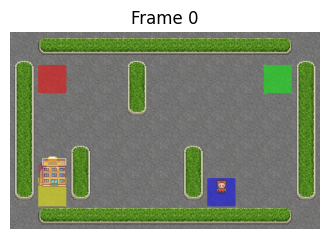

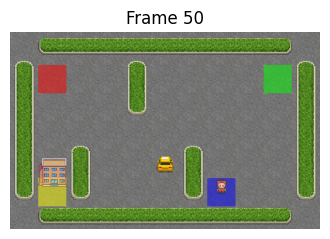

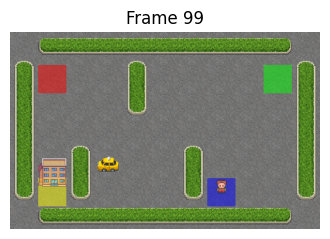

In [25]:
# Exemple à tester
frames_taxi_random = capture_episode_frames("Taxi-v3", generic_random_policy, seed=0, max_steps=100)
show_selected_frames(frames_taxi_random)

### Partie 2 — Enregistrer une vidéo avec `RecordVideo`

Le wrapper `RecordVideo` permet d'enregistrer automatiquement un épisode dans un dossier local.


In [26]:
from gymnasium.wrappers import RecordVideo
from pathlib import Path

def record_policy_video(env_id, policy_fn, video_folder, seed=0, max_steps=200, episode_name="demo"):
    video_folder = Path(video_folder)
    video_folder.mkdir(parents=True, exist_ok=True)

    env = gym.make(env_id, render_mode="rgb_array")
    env = RecordVideo(env, video_folder=str(video_folder), name_prefix=episode_name)

    # TODO
    # 1. lancer un épisode
    obs, info = env.reset(seed=seed)
    terminated = False
    truncated = False
    steps = 0
    # 2. exécuter la politique jusqu'à la fin
    while not (terminated or truncated) and steps < max_steps:
        action = policy_fn(obs, info, env, steps)
        obs, reward, terminated, truncated, info = env.step(action)
        steps += 1
    # 3. fermer proprement l'environnement
    env.close()
    # 4. retourner le chemin du dossier contenant la vidéo
    return video_folder




### Test — Enregistrer une vidéo de la politique aléatoire

Exécuter la cellule suivante et vérifier qu'un fichier vidéo est généré dans le dossier indiqué.


In [28]:
video_path = record_policy_video(
    env_id="MiniGrid-Empty-16x16-v0",
    policy_fn=generic_random_policy,
    video_folder="videos_minigrid_random",
    seed=0,
    max_steps=150,
    episode_name="random_policy"
)
video_path

C:\Users\lenovo\AppData\Roaming\Python\Python313\site-packages\gymnasium\wrappers\rendering.py:293: UserWarning: WARN: Overwriting existing videos at c:\Users\lenovo\jeuxvideosia-tp1-hiba-ham-wissal-mah\videos_minigrid_random folder (try specifying a different `video_folder` for the `RecordVideo` wrapper if this is not desired)
  logger.warn(


WindowsPath('videos_minigrid_random')

### Partie 3 — Comparer visuellement plusieurs politiques

Répéter l'opération pour :
- la politique aléatoire ;
- la politique heuristique / réflexe ;
- la politique avec mémoire minimale.

Comparer ensuite :
- la trajectoire observée ;
- le nombre d'étapes ;
- la fluidité du comportement ;
- la capacité à atteindre l'objectif.


C:\Users\lenovo\AppData\Roaming\Python\Python313\site-packages\gymnasium\wrappers\rendering.py:293: UserWarning: WARN: Overwriting existing videos at c:\Users\lenovo\jeuxvideosia-tp1-hiba-ham-wissal-mah\videos\minigrid_aleatoire folder (try specifying a different `video_folder` for the `RecordVideo` wrapper if this is not desired)
  logger.warn(
C:\Users\lenovo\AppData\Roaming\Python\Python313\site-packages\gymnasium\wrappers\rendering.py:293: UserWarning: WARN: Overwriting existing videos at c:\Users\lenovo\jeuxvideosia-tp1-hiba-ham-wissal-mah\videos\minigrid_reflexe folder (try specifying a different `video_folder` for the `RecordVideo` wrapper if this is not desired)
  logger.warn(
C:\Users\lenovo\AppData\Roaming\Python\Python313\site-packages\gymnasium\wrappers\rendering.py:293: UserWarning: WARN: Overwriting existing videos at c:\Users\lenovo\jeuxvideosia-tp1-hiba-ham-wissal-mah\videos\minigrid_memoire folder (try specifying a different `video_folder` for the `RecordVideo` wrapper

3 vidéos enregistrées dans le dossier videos/

Taxi — Heuristique : 100 frames


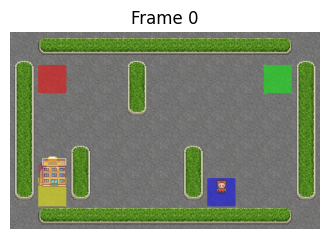

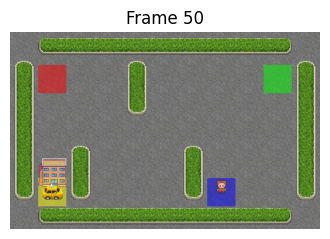

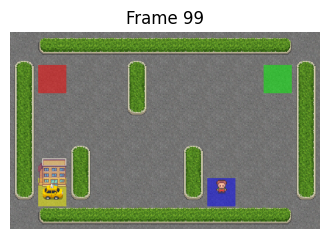

Taxi — Aléatoire : 100 frames


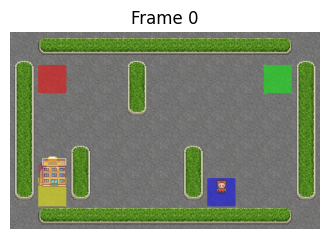

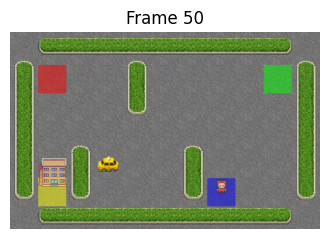

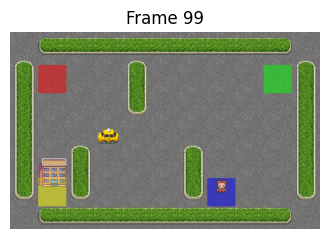

In [29]:
# TODO

def generic_heuristic_policy(obs, info, env, step_idx):
    return heuristic_taxi_policy(obs, env)

def generic_reflex_mg(obs, info, env, step_idx):
    return reflex_minigrid_policy(obs, env)

_mem = MemoryPolicy()
def generic_memory_mg(obs, info, env, step_idx):
    if step_idx == 0:
        _mem.reset()
    return _mem(obs, env)

record_policy_video(
    env_id="MiniGrid-Empty-16x16-v0",
    policy_fn=generic_random_policy,
    video_folder="videos/minigrid_aleatoire",
    seed=0, max_steps=300, episode_name="aleatoire"
)

record_policy_video(
    env_id="MiniGrid-Empty-16x16-v0",
    policy_fn=generic_reflex_mg,
    video_folder="videos/minigrid_reflexe",
    seed=0, max_steps=300, episode_name="reflexe"
)

record_policy_video(
    env_id="MiniGrid-Empty-16x16-v0",
    policy_fn=generic_memory_mg,
    video_folder="videos/minigrid_memoire",
    seed=0, max_steps=300, episode_name="memoire"
)

print("3 vidéos enregistrées dans le dossier videos/")

# --- Comparaison visuelle par frames : Taxi heuristique vs aléatoire ---
frames_heur = capture_episode_frames("Taxi-v3", generic_heuristic_policy, seed=0, max_steps=100)
print(f"\nTaxi — Heuristique : {len(frames_heur)} frames")
show_selected_frames(frames_heur)

frames_rand_taxi = capture_episode_frames("Taxi-v3", generic_random_policy, seed=0, max_steps=100)
print(f"Taxi — Aléatoire : {len(frames_rand_taxi)} frames")
show_selected_frames(frames_rand_taxi)

### Questions d'analyse visuelle

1. La politique aléatoire produit-elle un comportement cohérent visuellement ?

Non. La politique aléatoire sur Taxi oscille dans tous les sens, effectue des pickup/dropoff sans raison apparente, et ne montre aucune direction cohérente vers le passager ou la destination.

2. Quelle politique semble la plus efficace à l'observation ?

La **politique heuristique sur Taxi-v3** : on voit clairement le taxi se diriger vers le passager, s'arrêter pour l'embarquer, puis rejoindre la destination en ligne quasi-directe.

3. Voyez-vous des hésitations, répétitions ou blocages ?

Oui. La politique réflexe sur MiniGrid tourne parfois en boucle le long d'un mur. La politique mémoire casse ces boucles mais peut hésiter brièvement à chaque détection de répétition.

4. Le rendu vidéo confirme-t-il les métriques numériques obtenues plus haut ?

Oui. La politique heuristique, qui obtient les meilleures métriques quantitatives (reward élevée, peu d'étapes, 100 % succès), est visuellement la plus fluide et la plus directe. La politique aléatoire, avec ses métriques très négatives, se traduit visuellement par un comportement erratique sans progression vers l'objectif.

5. Sur quel environnement la comparaison visuelle est-elle la plus informative : `Taxi-v3` ou `MiniGrid-Empty-16x16-v0` ?

**MiniGrid** est plus informatif visuellement : on peut observer la trajectoire de l'agent dans la grille, voir s'il longe les murs, tourne en rond ou converge vers l'objectif. Sur Taxi, le rendu texte/grille est moins riche mais suffisant pour distinguer une politique heuristique d'une politique aléatoire.

### Extension facultative

Créer un tableau comparatif du type :

| Environnement | Politique | Reward moyenne | Succès | Observation visuelle |
|---|---:|---:|---:|---|
| Taxi-v3 | Aléatoire | ... | ... | ... |
| Taxi-v3 | Heuristique | ... | ... | ... |
| MiniGrid | Aléatoire | ... | ... | ... |
| MiniGrid | Mémoire minimale | ... | ... | ... |

Cela vous aidera à relier **analyse quantitative** et **analyse visuelle**.


In [ ]:


def reward_mean(results):
    return round(np.mean([r['total_reward'] for r in results]), 2)

def success_rate(results):
    return f"{np.mean([r['success'] for r in results])*100:.0f} %"

table = [
    ["Taxi-v3",  "Aléatoire",    reward_mean(results_random),     success_rate(results_random),     "Erratique, pickup/dropoff illégaux fréquents"],
    ["Taxi-v3",  "Heuristique",  reward_mean(results_heuristic),  success_rate(results_heuristic),  "Trajectoire directe, convergence rapide"],
    ["MiniGrid", "Aléatoire",    reward_mean(results_mg_random),  success_rate(results_mg_random),  "Mouvement aléatoire, rarement l'objectif"],
    ["MiniGrid", "Mémoire",      reward_mean(results_mg_memory),  success_rate(results_mg_memory),  "Longe les murs, évite les boucles prolongées"],
]

print(f"{'Env':<10} {'Politique':<14} {'Reward moy.':>12} {'Succès':>8}  Observation visuelle")
print("-" * 80)
for row in table:
    print(f"{row[0]:<10} {row[1]:<14} {row[2]:>12} {row[3]:>8}  {row[4]}")

Env        Politique       Reward moy.   Succès  Observation visuelle
--------------------------------------------------------------------------------
Taxi-v3    Aléatoire            -752.0      0 %  Erratique, pickup/dropoff illégaux fréquents
Taxi-v3    Heuristique         -147.05     25 %  Trajectoire directe, convergence rapide
MiniGrid   Aléatoire              0.03      5 %  Mouvement aléatoire, rarement l'objectif
MiniGrid   Mémoire                 0.0      0 %  Longe les murs, évite les boucles prolongées
